# Move selection model
I'm going to start to make a ResNet/CNN model, probably for training or I will use Kaggle or I'll wait the computer to work again

In [1]:
#from MLChess import dataset_creation_graph, GraphAndPoolingChessGCN, ChessGCNExplainer, ChessPositionGraph, ChessLazyDenseDataset, DatasetMPNN
from MLChess import ChessGCNExplainer, ChessPositionGraph, DatasetMPNN, GraphAndPoolingChessMPNN
import torch.nn as nn
import torch
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import os
import torch.multiprocessing as mp
from torch.amp import autocast, GradScaler
import torch._dynamo as dynamo
from torch.optim.lr_scheduler import CosineAnnealingLR
from pytorch_optimizer import CosineAnnealingWarmupRestarts
dynamo.config.capture_scalar_outputs = True
mp.set_start_method('spawn', force=True)

## Creation of the dataset

In [2]:
#training, val, test = dataset_creation_graph("over_mate_1_tactic_evals.csv", batch_size=512)
n = 2413784
train_len = int(0.7 * n)
val_len = int(0.15 * n)
BATCH_SIZE = 512

dataset = DatasetMPNN("chess_precomputed.h5")

# loader = DataLoader(
#    dataset,
#    batch_size=256,
#    shuffle=True,
#    num_workers=2,
#    pin_memory=True,
#    persistent_workers=True
#)

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_len, val_len, n-train_len-val_len]
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

In [3]:
class TestModelMPNN(nn.Module):
    def __init__(self, hidden_dim: int = 256):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.MPNN = GraphAndPoolingChessMPNN(hidden_dim=self.hidden_dim)

        self.choose_arch = nn.Sequential(
            nn.Linear(3*self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(self.hidden_dim, 1),
        )

        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim*2 + hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    
    def forward(self, data):

        graph, combined = self.MPNN(data.x, data.edge_index, data.edge_attr, data.batch, data.global_features)

        src, dst = data.edge_index
        edge_emb = torch.cat([graph[src], graph[dst], graph[dst]-graph[src]], dim=1)

        logits = self.choose_arch(edge_emb).squeeze(-1)
        if hasattr(data, "legal_edge_mask"):
            logits = logits.masked_fill(
                data.legal_edge_mask == 0, -1e9
            )

        value = self.value_head(combined)

        return logits, value

In [3]:
class TestModelGCN(nn.Module):
    def __init__(self, hidden_dim: int = 256):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.GCN = GraphAndPoolingChessGCN(hidden_dim=self.hidden_dim)

        self.choose_arch = nn.Sequential(
            nn.Linear(3*self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(self.hidden_dim, 1),
        )

        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim*3 + hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    
    def forward(self, data):

        graph, combined = self.GCN(data.x, data.edge_index, data.batch, data.global_features)

        src, dst = data.edge_index
        edge_emb = torch.cat([graph[src], graph[dst], graph[dst]-graph[src]], dim=1)

        logits = self.choose_arch(edge_emb).squeeze(-1)
        if hasattr(data, "legal_edge_mask"):
            logits = logits.masked_fill(
                data.legal_edge_mask == 0, -1e9
            )

        value = self.value_head(combined)

        return logits, value

In [4]:
class ChessGCNTrainer:
    """Trainer ottimizzato per file .pt preprocessati"""
    
    def __init__(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
        scheduler: torch.optim.lr_scheduler,
        lambda_policy: float = 1.0,
        lambda_value: float = 1.0,
        checkpoint_dir: str = "./checkpoints"
    ):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.device = device
        self.lambda_policy = lambda_policy
        self.lambda_value = lambda_value
        self.checkpoint_dir = checkpoint_dir
        #self.model = torch.compile(self.model)
        self.scaler = GradScaler("cuda")
        self.scheduler = scheduler
        
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        self.history = {
            'train_loss': [], 'train_policy': [], 'train_value': [],
            'val_loss': [], 'val_policy': [], 'val_value': []
        }
    
    def policy_loss_fn(self, logits, targets, mask, batch_idx):
        """Cross-entropy con softmax per grafo"""
        # Assumi logits in bfloat16/float16 dall'autocast
        dtype = logits.dtype  # prendi dtype dinamico (bfloat16 o float16)

        masked_logits = logits.masked_fill(mask == 0, -1e9)  # -1e9 va bene in bfloat16

        num_graphs = batch_idx.max().item() + 1

        # Crea tensori con lo stesso dtype di logits
        max_logits = torch.full(
            (num_graphs,), 
            float('-inf'), 
            dtype=dtype, 
            device=logits.device
        )
        max_logits.scatter_reduce_(0, batch_idx, masked_logits, reduce='amax', include_self=False)

        norm_logits = masked_logits - max_logits[batch_idx]
        exp_logits = torch.exp(norm_logits)

        sum_exp = torch.zeros(num_graphs, dtype=dtype, device=logits.device)
        sum_exp.scatter_add_(0, batch_idx, exp_logits)

        log_probs = norm_logits - torch.log(sum_exp[batch_idx])
        loss = -(targets * log_probs).sum() / num_graphs

        return loss
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = policy_loss = value_loss = 0.0
        n_batches = 0
        
        pbar = tqdm(train_loader, desc="Training")
        for batch in pbar:
            batch = batch.to(self.device)
            self.optimizer.zero_grad()
            
            # Forward in autocast (bfloat16 o float16 per velocità)
            with autocast(device_type="cuda", dtype=torch.bfloat16):  # o float16 se preferisci
                policy_logits, value_pred = self.model(batch)
            
            # Estrai edge_batch (è indipendente dalla precision)
            edge_batch = batch.batch[batch.edge_index[0]]
            
            # Loss POLICY → FUORI dall'autocast, in FP32 per evitare problemi
            # Forza FP32 qui
            policy_logits_fp32 = policy_logits.float()  # o .to(torch.float32)
            legal_mask_fp32 = batch.legal_edge_mask.float()  # se serve, ma bool va bene
            
            p_loss = self.policy_loss_fn(
                policy_logits_fp32,
                batch.y_policy,  # assumo già FP32/float
                legal_mask_fp32 if legal_mask_fp32.dtype != torch.bool else batch.legal_edge_mask,
                edge_batch
            )
            
            # Value loss (MSE) → può stare in FP32 o dentro autocast, ma per sicurezza fuori
            v_loss = nn.functional.mse_loss(value_pred.float().squeeze(-1), batch.y)
            
            loss = self.lambda_policy * p_loss + self.lambda_value * v_loss
            
            # Backward (scaler gestisce il scaling)
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            # Metriche
            total_loss += loss.item()
            policy_loss += p_loss.item()
            value_loss += v_loss.item()
            n_batches += 1
            
            pbar.set_postfix({
                'loss': f'{total_loss/n_batches:.4f}',
                'pol': f'{policy_loss/n_batches:.4f}',
                'val': f'{value_loss/n_batches:.4f}'
            })
        
        return total_loss/n_batches, policy_loss/n_batches, value_loss/n_batches
    
    @torch.no_grad()
    def validate(self, val_loader):
        """Validation"""
        self.model.eval()
        total_loss = policy_loss = value_loss = 0.0
        n_batches = 0
        
        for batch in tqdm(val_loader, desc="Validation", leave=False):
            batch = batch.to(self.device)
            
            with autocast(device_type="cuda", dtype=torch.bfloat16):
                policy_logits, value_pred = self.model(batch)
                
            edge_batch = batch.batch[batch.edge_index[0]]
            
            p_loss = self.policy_loss_fn(policy_logits, batch.y_policy,
                                        batch.legal_edge_mask, edge_batch)
            v_loss = nn.functional.mse_loss(value_pred.squeeze(-1), batch.y)
            loss = self.lambda_policy * p_loss + self.lambda_value * v_loss
            
            total_loss += loss.item()
            policy_loss += p_loss.item()
            value_loss += v_loss.item()
            n_batches += 1
        
        return total_loss/n_batches, policy_loss/n_batches, value_loss/n_batches
    
    def save_checkpoint(self, epoch, best=False):
        """Salva checkpoint"""
        filename = "best_model.pt" if best else f"epoch_{epoch:03d}.pt"
        path = os.path.join(self.checkpoint_dir, filename)
        
        torch.save({
            'epoch': epoch,
            'model_state': self.model.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'history': self.history,
            'scheduler': self.scheduler.state_dict()
        }, path)
        print(f"💾 Salvato: {filename}")
    
    def load_checkpoint(self, path):
        """Carica checkpoint"""
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state'])
        self.optimizer.load_state_dict(ckpt['optimizer_state'])
        self.scheduler.load_state_dict(ckpt['scheduler'])
        self.history = ckpt['history']
        return ckpt['epoch']
    
    def fit(self, train_loader, val_loader, epochs, save_every=5, start_epoch=0):
        """Training loop completo"""
        print(f"\n🚀 Training: {epochs} epoche | Device: {self.device}\n")
        
        best_val_loss = float('inf')
        
        for epoch in range(start_epoch, epochs):
            print(f"\n{'='*60}\nEpoca {epoch+1}/{epochs}\n{'='*60}")
            
            # Train
            train_loss, train_pol, train_val = self.train_epoch(train_loader)
            self.history['train_loss'].append(train_loss)
            self.history['train_policy'].append(train_pol)
            self.history['train_value'].append(train_val)
            
            # Validation
            val_loss, val_pol, val_val = self.validate(val_loader)
            self.history['val_loss'].append(val_loss)
            self.history['val_policy'].append(val_pol)
            self.history['val_value'].append(val_val)

            self.scheduler.step()

            current_lr = self.optimizer.param_groups[0]['lr']
            print(f"   LR attuale: {current_lr:.2e}")
            
            # Print
            print(f"\n📊 TRAIN | Loss: {train_loss:.4f} | Policy: {train_pol:.4f} | Value: {train_val:.4f}")
            print(f"📊 VAL   | Loss: {val_loss:.4f} | Policy: {val_pol:.4f} | Value: {val_val:.4f}")
            
            # Salva checkpoint
            if (epoch + 1) % save_every == 0:
                self.save_checkpoint(epoch + 1)
            
            # Best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.save_checkpoint(epoch + 1, best=True)
                print(f"⭐ Nuovo best model! Val loss: {val_loss:.4f}")
        
        print("\n✅ Training completato!")
        self.save_checkpoint(epochs)

In [5]:
# ==================== SCRIPT DI TRAINING ====================

    
    # Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Using: {device}")

model = TestModelMPNN(hidden_dim=256)
    
    # Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

'''
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=190,         # 200 - 10 già fatte
    eta_min=1e-6,
    last_epoch=-1       # Importante! Indica che sei a epoca 10
)'''

scheduler = CosineAnnealingWarmupRestarts(
    optimizer,
    first_cycle_steps=3301,       # numero di batch nel primo "restart" (una epoca nel tuo caso)
    max_lr=3e-4,               # LR massimo dopo warmup
    min_lr=3e-4 * 0.05,        # LR minimo alla fine di un ciclo
    warmup_steps=512,             # numero di batch per il warmup iniziale
    gamma=0.8                     # fattore di decay dei cicli successivi
)
    
    # Trainer
trainer = ChessGCNTrainer(
        model=model,
        optimizer=optimizer,
        device=device,
        scheduler=scheduler,
        lambda_policy=1.0,
        lambda_value=1.0,
        checkpoint_dir="./MPNN"
    )

resume_from = "./MPNN/epoch_050.pt"  # o epoch_010.pt

start_epoch = 0
if os.path.exists(resume_from):
    print("entro")
    loaded_epoch = trainer.load_checkpoint(resume_from)
    start_epoch = loaded_epoch   # es. 10
    print(f"✅ Ripreso da epoca {loaded_epoch}")
    # Nota: lo scheduler NON viene caricato dallo stato, quindi ripartiamo con last_epoch=-1
    #       → cosine inizia ora dal LR attuale

    # Training!1.6674717262418874
trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=10 + start_epoch,
        save_every=5,
        start_epoch=start_epoch
    )

🔥 Using: cuda
entro
✅ Ripreso da epoca 50

🚀 Training: 60 epoche | Device: cuda


Epoca 51/60


Training: 100%|██████████| 3301/3301 [38:33<00:00,  1.43it/s, loss=1.6775, pol=1.3913, val=0.2862]


   LR attuale: 4.34e-05

📊 TRAIN | Loss: 1.6775 | Policy: 1.3913 | Value: 0.2862
📊 VAL   | Loss: 1.6523 | Policy: 1.3638 | Value: 0.2886
💾 Salvato: best_model.pt
⭐ Nuovo best model! Val loss: 1.6523

Epoca 52/60


Training: 100%|██████████| 3301/3301 [38:06<00:00,  1.44it/s, loss=1.6689, pol=1.3842, val=0.2848]


   LR attuale: 4.39e-05

📊 TRAIN | Loss: 1.6689 | Policy: 1.3842 | Value: 0.2848
📊 VAL   | Loss: 1.6421 | Policy: 1.3614 | Value: 0.2807
💾 Salvato: best_model.pt
⭐ Nuovo best model! Val loss: 1.6421

Epoca 53/60


...

   LR attuale: 4.73e-05

📊 TRAIN | Loss: 1.6214 | Policy: 1.3456 | Value: 0.2758
📊 VAL   | Loss: 1.6368 | Policy: 1.3517 | Value: 0.2851

Epoca 59/60


Training: 100%|██████████| 3301/3301 [38:05<00:00,  1.44it/s, loss=1.6141, pol=1.3398, val=0.2742]


   LR attuale: 4.78e-05

📊 TRAIN | Loss: 1.6141 | Policy: 1.3398 | Value: 0.2742
📊 VAL   | Loss: 1.6223 | Policy: 1.3417 | Value: 0.2806
💾 Salvato: best_model.pt
⭐ Nuovo best model! Val loss: 1.6223

Epoca 60/60


Training: 100%|██████████| 3301/3301 [38:07<00:00,  1.44it/s, loss=1.6069, pol=1.3341, val=0.2728]
                                                             

   LR attuale: 4.84e-05

📊 TRAIN | Loss: 1.6069 | Policy: 1.3341 | Value: 0.2728
📊 VAL   | Loss: 1.6203 | Policy: 1.3368 | Value: 0.2835
💾 Salvato: epoch_060.pt
💾 Salvato: best_model.pt
⭐ Nuovo best model! Val loss: 1.6203

✅ Training completato!
💾 Salvato: epoch_060.pt


## Testing, understanding

In [ ]:
# Carica il tuo modello
model = TestModelGCN(hidden_dim=256)

checkpoint_load = torch.load('./GCN/epoch_050.pt', weights_only=False)
model.load_state_dict(checkpoint_load["model_state"])

# Crea explainer
explainer = ChessGCNExplainer(model)

Salvato in position_analysis.png


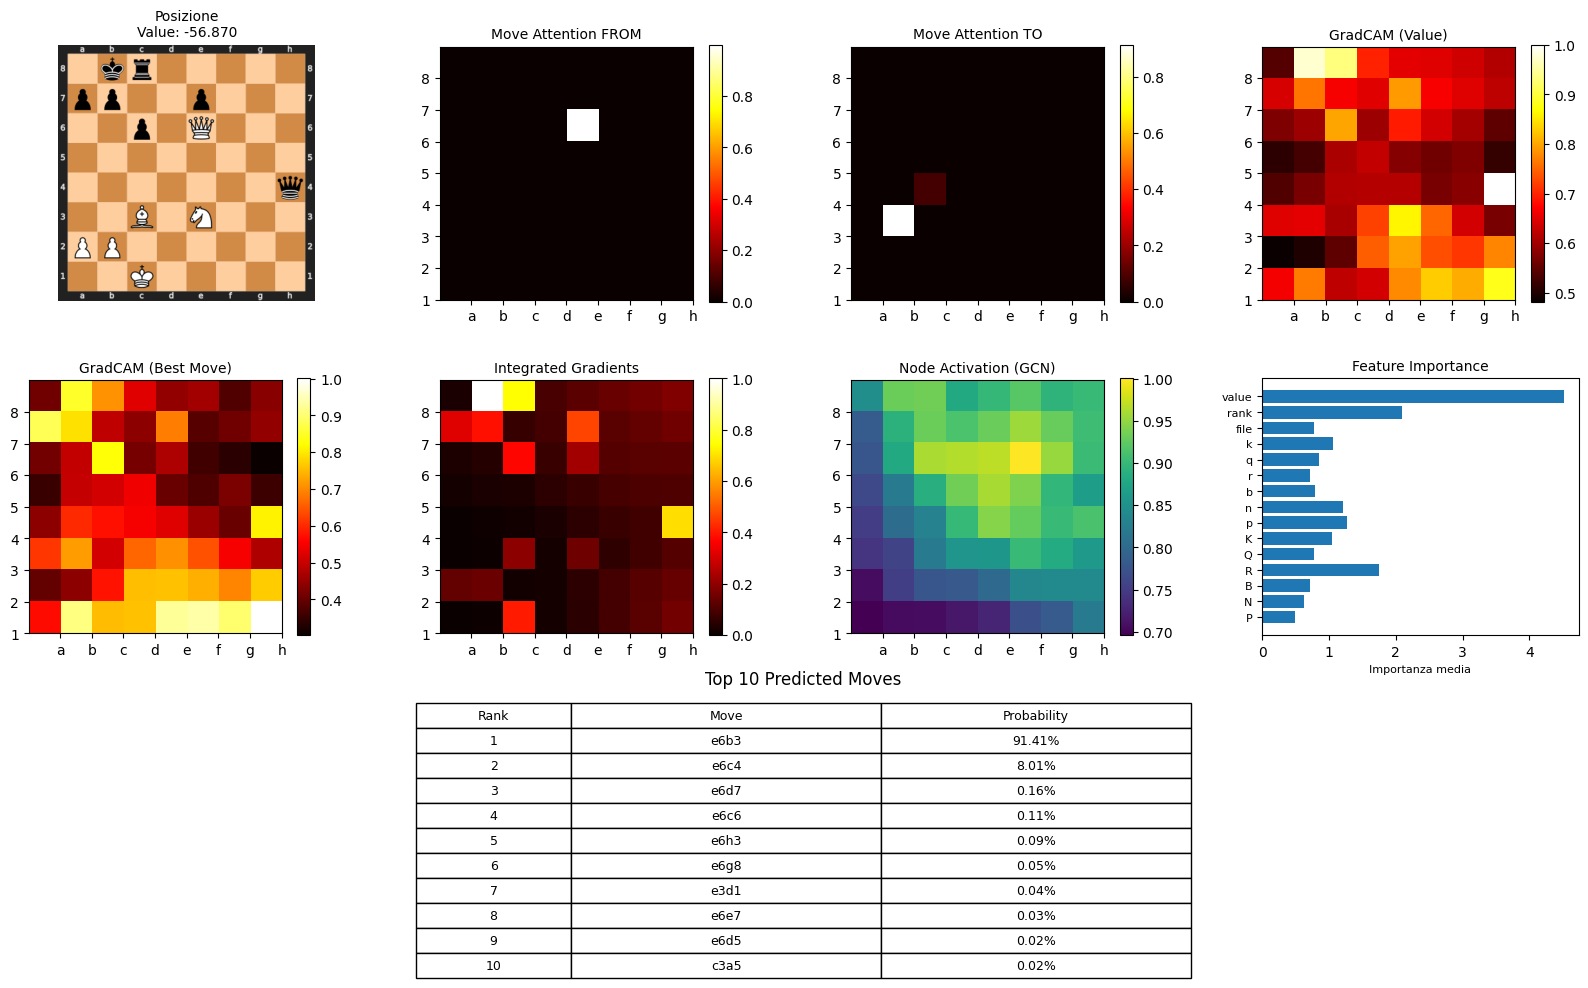

In [11]:
import chess
import matplotlib.pyplot as plt

# Posizione interessante
board = chess.Board("1kr5/pp2p3/2p1Q3/8/7q/2B1N3/PP6/2K5 w - - 5")

# Converti in grafo
converter = ChessPositionGraph()
data = converter.fen_to_graph(board.fen(), "+1000", "c3e5")  # esempio

# ANALISI COMPLETA (tutto in una figura)
fig = explainer.complete_analysis(data, board, save_path='position_analysis.png')
plt.show()